In [1]:
!pip install scikit-optimize

In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing    import LabelEncoder
from sklearn.utils            import compute_class_weight
from sklearn.model_selection  import StratifiedKFold
from xgboost                  import XGBClassifier
from sklearn.decomposition import PCA

from skopt                    import BayesSearchCV

In [3]:
df = pd.read_pickle('df_final_embeddings.pkl') # dtaaframe z embeddingami

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2491 entries, Inception to Theater Camp
Columns: 230 entries, adult to overview_embedding
dtypes: bool(1), category(1), float64(2), int64(224), object(2)
memory usage: 4.4+ MB


In [5]:
for col in df.select_dtypes(include=['bool']).columns:
    df[col] = df[col].astype(int)

In [6]:
df.drop(columns='target_value', inplace=True)

In [7]:
def unpack_embedding_column(df: pd.DataFrame, col_name: str, prefix: str) -> pd.DataFrame:
    """
    Rozpakuj kolumnę embeddingów (lista lub np.array) na osobne kolumny.
    Jeśli wartość jest NaN lub nie-listą, zastępujemy wektorem zer.
    """
    # znajdź wymiar embeddingu na podstawie pierwszego niepustego rekordu
    non_null = df[col_name].dropna()
    if len(non_null) == 0:
        # brak żadnych embeddingów
        return pd.DataFrame(index=df.index)
    first = non_null.iloc[0]
    emb_dim = len(first) if isinstance(first, (list, np.ndarray)) else 0

    # zastąp pustki zerami i stwórz DataFrame z list
    emb_series = df[col_name].apply(
        lambda x: x if isinstance(x, (list, np.ndarray)) else [0]*emb_dim
    )
    emb_df = pd.DataFrame(emb_series.tolist(), index=df.index)
    emb_df.columns = [f"{prefix}_{i}" for i in range(emb_df.shape[1])]
    return emb_df

In [8]:
if 'overview_embedding' in df.columns:
    overview_emb_df = unpack_embedding_column(df, 'overview_embedding', 'overview_emb')
else:
    overview_emb_df = pd.DataFrame(index=df.index)

if 'keywords_embedding' in df.columns:
    keywords_emb_df = unpack_embedding_column(df, 'keywords_embedding', 'keywords_emb')
else:
    keywords_emb_df = pd.DataFrame(index=df.index)

In [9]:
df = df.drop(columns=[c for c in ['overview_embedding','keywords_embedding'] if c in df.columns])
df = pd.concat([df, overview_emb_df, keywords_emb_df], axis=1)

In [10]:
feature_cols = [
    col for col in df.columns
    if col not in ['label']
]
X = df[feature_cols]

In [11]:
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

In [12]:
emb_cols = [c for c in X.columns if 'emb_' in c]
other_cols = [c for c in X.columns if c not in emb_cols]

In [13]:
len(emb_cols)

2048

In [14]:
X_emb = X[emb_cols].values
# reduce to 200 dims ~ 85 % wariancji
pca = PCA(n_components=200, random_state=42)
X_emb_pca = pca.fit_transform(X_emb)

In [15]:
X_other = X[other_cols].values
X_proc = np.concatenate([X_emb_pca, X_other], axis=1)

In [16]:
print("Rozkład klas:\n", df['label'].value_counts())

Rozkład klas:
 label
Hit            804
Flop           730
Average        492
Blockbuster    465
Name: count, dtype: int64


In [17]:
classes      = np.unique(y_encoded)
class_weights = compute_class_weight('balanced', classes=classes, y=y_encoded)
weight_dict   = dict(zip(classes, class_weights))
print("Wagi klas:", weight_dict)

Wagi klas: {np.int64(0): np.float64(1.2657520325203253), np.int64(1): np.float64(1.339247311827957), np.int64(2): np.float64(0.8530821917808219), np.int64(3): np.float64(0.7745646766169154)}


In [18]:
X = X_proc
y = y_encoded
sample_weights = np.array([ weight_dict[c] for c in y ])

In [19]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [20]:
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(classes),
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

In [21]:
param_space = {
    'max_depth'        : (3, 6),
    'learning_rate'    : (0.01, 0.3, 'log-uniform'),
    'n_estimators'     : (50, 200),
    'subsample'        : (0.5, 0.7, 'uniform'),
    'colsample_bytree' : (0.1, 0.3, 'uniform'),
    'gamma'            : (0, 1, 'uniform'),
    'min_child_weight' : (1, 5),
    'reg_alpha'        : (1e-8, 1e-1, 'log-uniform'),
    'reg_lambda'       : (1e-8, 1.0, 'log-uniform'),
}

In [22]:
bayes_search = BayesSearchCV(
    estimator     = xgb,
    search_spaces = param_space,
    n_iter        = 10,
    cv            = cv,
    scoring       = 'f1_macro',
    n_jobs        = -1,
    refit         = True,
    verbose       = 1
)

In [23]:
bayes_search.fit(X, y, sample_weight=sample_weights)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:08:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


BayesSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None, device=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=False,
                                      eval_metric='mlogloss',
                                      feature_types=None, gamma=None,
                                      grow_policy=None, importa...
                                      num_parallel_tree=None, ...),
              n_iter=10, n_jobs=-1, scoring='f1_macro',
              search_spaces={'colsample_bytree': (0.1, 0.3, 'uniform'),
                             'gamma': (0, 1, 'uniform'),
                             'learning_rate': (0.01, 0.3, 'log-uniform'),
                             'max_depth': (3, 6), 'min_child_weight': (1, 5),
                             'n_estimators': (50, 200),
                             'reg_alpha': (1e-08, 0.1, 'log-uniform'),
                             'reg_lambda': (1e-08, 1.0, 'log-uniform'),
                             'subsample': (0.5, 0.7, 'uniform')},
              verbose=1)

In [24]:
print("\nNajlepsze parametry:", bayes_search.best_params_)
print("Najlepszy CV log-loss:", -bayes_search.best_score_)


Najlepsze parametry: OrderedDict([('colsample_bytree', 0.2805082732034777), ('gamma', 1), ('learning_rate', 0.016948649707313853), ('max_depth', 4), ('min_child_weight', 4), ('n_estimators', 68), ('reg_alpha', 1.0018472260535531e-06), ('reg_lambda', 0.0625486663535263), ('subsample', 0.5950121497863419)])
Najlepszy CV log-loss: -0.31864655152886684


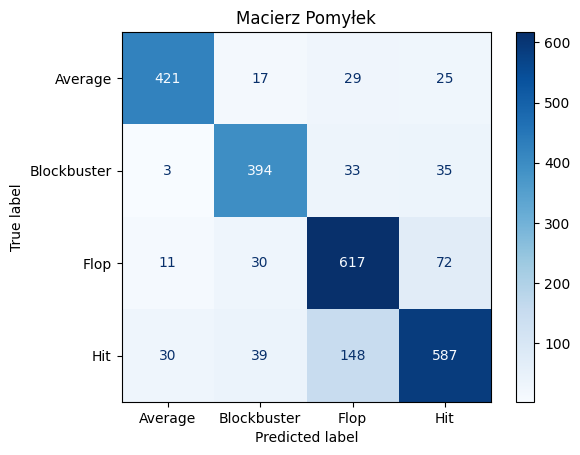

In [25]:
# prompt: wygeneruj macierz pomyłek

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the entire dataset with the best model found
y_pred = bayes_search.predict(X)

# Generate the confusion matrix
cm = confusion_matrix(y, y_pred)

# Get the class labels
class_labels = le.classes_

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Macierz Pomyłek')
plt.show()


In [26]:
# prompt: pokaz najwazniejsze miary dobroci tego modelu

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Evaluate the model
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, average='macro') # Use macro for multi-class
recall = recall_score(y, y_pred, average='macro') # Use macro for multi-class
f1 = f1_score(y, y_pred, average='macro') # Use macro for multi-class

print(f"\nDokładność (Accuracy): {accuracy:.4f}")
print(f"Precyzja (Precision - Macro): {precision:.4f}")
print(f"Czułość (Recall - Macro): {recall:.4f}")
print(f"Wynik F1 (F1-score - Macro): {f1:.4f}")

# Detailed classification report
print("\nSzczegółowy raport klasyfikacji:")
print(classification_report(y, y_pred, target_names=class_labels))



Dokładność (Accuracy): 0.8105
Precyzja (Precision - Macro): 0.8222
Czułość (Recall - Macro): 0.8196
Wynik F1 (F1-score - Macro): 0.8193

Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

     Average       0.91      0.86      0.88       492
 Blockbuster       0.82      0.85      0.83       465
        Flop       0.75      0.85      0.79       730
         Hit       0.82      0.73      0.77       804

    accuracy                           0.81      2491
   macro avg       0.82      0.82      0.82      2491
weighted avg       0.81      0.81      0.81      2491



In [27]:
!pip install shap

In [46]:
import shap
import numpy as np
import pandas as pd

# Use the best estimator from BayesSearchCV
best_model = bayes_search.best_estimator_

# Create a SHAP explainer
# Using the entire dataset for the background distribution might be slow for large datasets.
# A sample of the data can be used instead if needed.
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for the entire dataset
# It seems shap_values is a list of arrays, one for each class
shap_values = explainer.shap_values(X)

# Print the shape of the overall shap_values object
print(f"Shape of shap_values: {np.shape(shap_values)}")


# Get the feature names. Need to create new names for the PCA components
# and combine them with the names of the other features.
pca_feature_names = [f'pca_emb_{i}' for i in range(X_emb_pca.shape[1])]
other_feature_names = other_cols
feature_names = pca_feature_names + other_feature_names

print(f"Length of feature_names: {len(feature_names)}")

# Create a dictionary to store top features for each class
top_features_per_class = {}

for i, class_name in enumerate(class_names):
    # Correctly slice the shap_values to get values for the current class across all samples
    shap_values_class_i = shap_values[:, :, i]

    # Print the shape of the shap_values array for the current class
    print(f"Shape of shap_values for class '{class_name}': {np.shape(shap_values_class_i)}")

    # Calculate the mean absolute SHAP value for each feature for the current class
    mean_abs_shap_values = np.abs(shap_values_class_i).mean(axis=0)

    # Add a check for the lengths
    if len(mean_abs_shap_values) != len(feature_names):
        print(f"Mismatch in lengths for class '{class_name}':")
        print(f"Length of mean_abs_shap_values: {len(mean_abs_shap_values)}")
        print(f"Length of feature_names: {len(feature_names)}")
        # Optionally, you could break or handle this mismatch
        # For now, we'll let the ValueError happen to confirm the lengths
        pass # Allow the ValueError to occur for now

    # Create a pandas Series for easier sorting
    shap_series = pd.Series(mean_abs_shap_values, index=feature_names)

    # Get the top 15 features for the current class
    top_features = shap_series.sort_values(ascending=False).head(15)

    top_features_per_class[class_name] = top_features

# Print the top 15 features for each class
for class_name, top_features in top_features_per_class.items():
    print(f"\nTop 15 features for class: {class_name}")
    print(top_features)

Shape of shap_values: (2491, 426, 4)
Length of feature_names: 426
Shape of shap_values for class 'Average': (2491, 426)
Shape of shap_values for class 'Blockbuster': (2491, 426)
Shape of shap_values for class 'Flop': (2491, 426)
Shape of shap_values for class 'Hit': (2491, 426)

Top 15 features for class: Average
pca_emb_15     0.014564
pca_emb_49     0.009046
pca_emb_166    0.007942
pca_emb_183    0.007698
pca_emb_198    0.007377
pca_emb_176    0.007295
pca_emb_7      0.006908
pca_emb_172    0.006663
pca_emb_158    0.006559
pca_emb_141    0.006347
pca_emb_79     0.006070
pca_emb_127    0.005774
pca_emb_26     0.005417
pca_emb_19     0.005331
pca_emb_78     0.005313
dtype: float32

Top 15 features for class: Blockbuster
pca_emb_1       0.018532
genre_Horror    0.015512
pca_emb_2       0.014178
pca_emb_23      0.012981
pca_emb_45      0.012376
pca_emb_180     0.009878
pca_emb_106     0.008565
pca_emb_19      0.008445
pca_emb_130     0.008406
pca_emb_7       0.008057
genre_Action    0.00